<a href="https://colab.research.google.com/github/Kidkudos77/personalportfolio/blob/main/Chapter3_Bayesian_Regression_cls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **This example illustrates how Bayesian regression can mitigate the overfitting issue in regression analysis.**

First, the same as before. We generate data and use cubic spline with 80 knots to create an overfit model.

In [1]:
import numpy as np
from scipy import linalg
import matplotlib.pyplot as plt

x = np.linspace(-4, 4, 100)
y = 10 * np.sin(2*x)
yn = y + np.random.normal(0, 5, size=y.shape)


<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:21: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:21: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_791/4172800864.py:20: SyntaxWarning: invalid escape sequence '\o'
  plt.plot(x, y, 'b', label="$f(x;\omega)$")
/tmp/ipykernel_791/4172800864.py:21: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(x, y_pred, 'r', label="$\hat{f}(x;\omega)$")


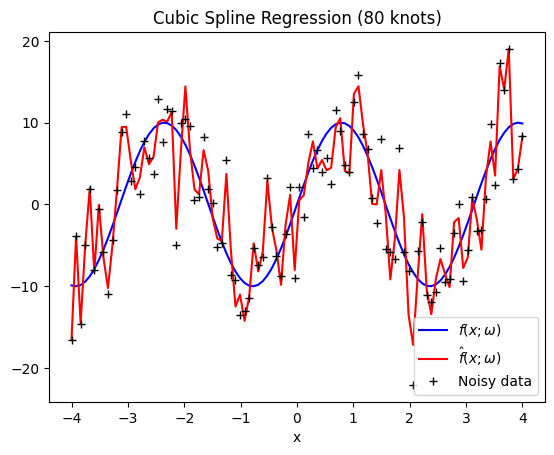

In [2]:
# working a spline regression (piecewise cubic)

# polynomial degree = 3
pfun = lambda x,degree: np.power((np.abs(x) + x)/2, degree).reshape(-1)
degree = 3
One = np.ones(x.shape)

# create basis matrix following Equation (3.12), 80 knot locations uniformly over [-4, 4]
knots = np.linspace(-3.9, 3.9, 80)
# X is Phi(x)^T in the lecture slide. It includes columns 1, x, x^2, x^3, [(x-kj)+]^3...
# X has 84 columns. Its number of rows is determined by the number of data points in x
X = np.column_stack((One, x, np.power(x, 2), np.power(x, 3)))
for k in knots:
  X = np.column_stack((X, pfun(x-k, degree)))

w = np.linalg.solve(X.T @ X, X.T @ yn)

y_pred = X @ w
# Plot the results
plt.plot(x, y, 'b', label="$f(x;\omega)$")
plt.plot(x, y_pred, 'r', label="$\hat{f}(x;\omega)$")
plt.plot(x, yn, 'k+', label="Noisy data")

plt.xlabel('x')
plt.title('Cubic Spline Regression (80 knots)')
plt.legend()
plt.show()

# **Part 1: Develop Bayesian regressoin to address the overfitting issue above.**

<>:22: SyntaxWarning: invalid escape sequence '\o'
<>:23: SyntaxWarning: invalid escape sequence '\h'
<>:22: SyntaxWarning: invalid escape sequence '\o'
<>:23: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_791/1305777010.py:22: SyntaxWarning: invalid escape sequence '\o'
  plt.plot(x, y, 'b', label="$f(x;\omega)$")
/tmp/ipykernel_791/1305777010.py:23: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(x, y_pred_b, 'r', label="$\hat{f}(x;\omega)$")


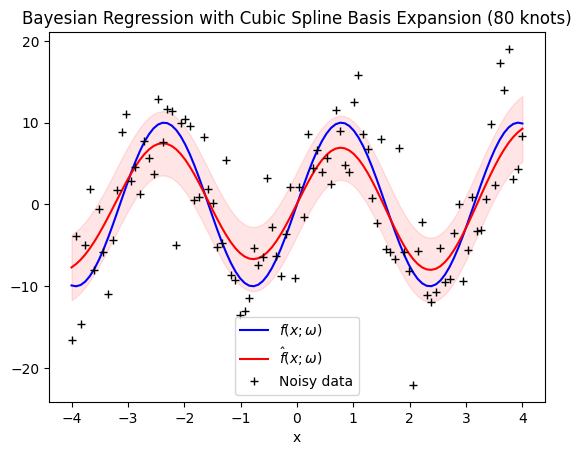

In [8]:
# prior distribution of w ~ N(mu0, S0)

p   =  X.shape[1] # Extract the number of dimensions. X shape 100X84. There are 84 bases in the expansion
mu0 = np.zeros((p, 1))  # zero mean
S0  = np.identity(p) # identity matrix scaled

# In reality, we do not know the value for sigma_hat^2
# It can only be estimated from sample variance in the earlier spline regression
sigma2_hat = np.power(yn-y_pred,2).mean()
# Using the conclusion on Slide 33 of Chapter 3
S0i = np.linalg.inv(S0) # inverse of covariance S0, precision
SigmaN = np.linalg.inv(S0i+X.T@X/sigma2_hat)
muN = SigmaN @ (S0i@mu0 + (X.T@yn.reshape(-1,1))/sigma2_hat)

# posterior predictive distribution
# Use the results on slide 35 below (3.22)
y_pred_b = (X@muN).flatten() # convert from 2D array- column vector to 1D- row vector to match size with other vectors
y_sig2 = sigma2_hat + np.diag(X@SigmaN@X.T)

ci = 1.96 * np.sqrt(y_sig2)

plt.plot(x, y, 'b', label="$f(x;\omega)$")
plt.plot(x, y_pred_b, 'r', label="$\hat{f}(x;\omega)$")
plt.plot(x, yn, 'k+', label="Noisy data")
plt.fill_between(x, (y_pred_b-ci), (y_pred_b+ci), color='red', alpha=0.1)
plt.xlabel('x')
plt.title('Bayesian Regression with Cubic Spline Basis Expansion (80 knots)')
plt.legend()
plt.show()

# **Part 2: Develop Bayesian Kernel regression to address the overfitting issue.**
Bayesian regression uses the same conclusion as Slide 33 of Chapter 3. The only difference is that how X is computed. It is estimated by Gaussian Kernal instead of column stacking of x polynomials.

<>:29: SyntaxWarning: invalid escape sequence '\o'
<>:30: SyntaxWarning: invalid escape sequence '\h'
<>:29: SyntaxWarning: invalid escape sequence '\o'
<>:30: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_791/2756663936.py:29: SyntaxWarning: invalid escape sequence '\o'
  plt.plot(x, y, 'b', label="$f(x;\omega)$")
/tmp/ipykernel_791/2756663936.py:30: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(x, y_pred, 'r', label="$\hat{f}(x;\omega)$")


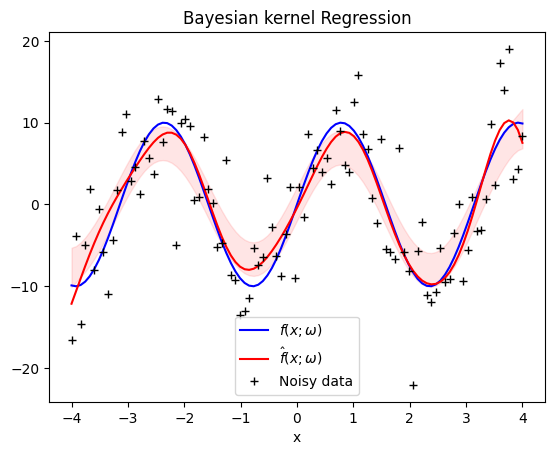

In [9]:
# Bayesian kernel regression

from sklearn.metrics.pairwise import euclidean_distances

def gaussian_kernel(x1, x2, s):
    return np.exp(-np.power(euclidean_distances(x1, x2), 2)/(2*s**2))

s = 1
X = gaussian_kernel(x.reshape(-1, 1), x.reshape(-1, 1), s) # Data size 100X100
p   = X.shape[1] # dimension of data
mu0 = np.zeros(p)# zero mean
# Choose a prior for variance regulated by alpha
# Larger alpha, prior variance close to 0 less flexibility. Smaller alpha, prior variance is large
# bigger alpha, smoother the fitted curve (prediction)
alpha = 0.000001
S0  = np.identity(p)

# posterior distribution of w ~ N(muN, SN), from Slide #33 of Chapter 3
S0i = alpha * np.eye(p)
SigmaN = np.linalg.inv(S0i + (1/sigma2_hat) * X.T @ X)
muN = SigmaN @ (S0i @ mu0 + (1/sigma2_hat) * X.T @ yn)

# posterior predictive distribution. Slide #33
y_pred = (X @ muN).reshape(-1)
y_sig2 = sigma2_hat + np.diag(X @ SigmaN @ X.T)

ci = np.sqrt(y_sig2)

plt.plot(x, y, 'b', label="$f(x;\omega)$")
plt.plot(x, y_pred, 'r', label="$\hat{f}(x;\omega)$")
plt.plot(x, yn, 'k+', label="Noisy data")
plt.fill_between(x, (y_pred_b-ci), (y_pred_b+ci), color='red', alpha=0.1)
plt.xlabel('x')
plt.title('Bayesian kernel Regression')
plt.legend()
plt.show()